Dataset shape: (500000, 8)
   CustomerID InvoiceNo  Product  Category  Quantity  UnitPrice  \
0         626  f3cab97a      Yes   Dresses         1      84.62   
1        2539  524f91dd      Buy      Tops         4      35.76   
2        5515  d848420a  Special   Dresses         2     286.96   
3        7767  baa9ea64   Summer  Footwear         4      83.15   
4        7221  2414bb41  Popular      Tops         3      53.83   

           InvoiceDate  TotalAmount  
0  2025-08-25 21:13:31        84.62  
1  2025-10-22 07:47:01       143.04  
2  2025-08-09 16:25:09       573.92  
3  2025-08-30 16:09:54       332.60  
4  2025-07-26 13:06:38       161.49  

RFM Table:
   CustomerID  Recency  Frequency  Monetary
0           1        4         59   7769.26
1           2        1        142  65896.07
2           3        6          3    388.38
3           4      163          1    245.94
4           5        6         78   9889.63


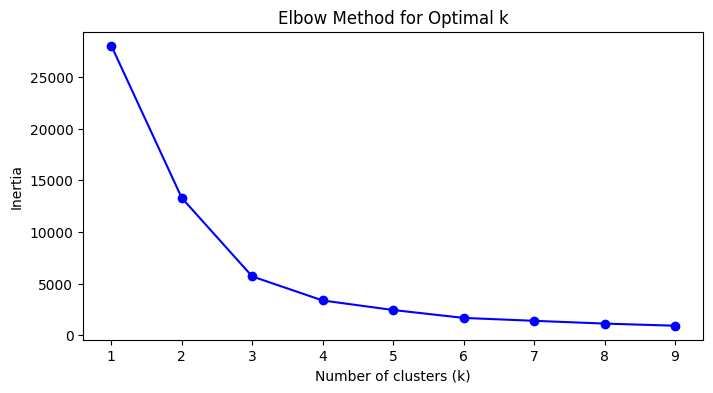


Cluster Summary:
   Cluster     Recency   Frequency      Monetary  NumCustomers
0        0    4.854604   87.988691  14403.523788          2476
1        1  127.814958    2.436011    491.526078          1805
2        2    2.643082  178.867138  89664.260079          1272
3        3   26.103766   13.227285   2969.161912          3797

Segmented Data (Sample):
   CustomerID  Recency  Frequency  Monetary  Cluster               Segment
0           1        4         59   7769.26        0  High-Value Loyalists
1           2        1        142  65896.07        2       One-time Buyers
2           3        6          3    388.38        3           Churn Risks
3           4      163          1    245.94        1       Bargain Seekers
4           5        6         78   9889.63        0  High-Value Loyalists


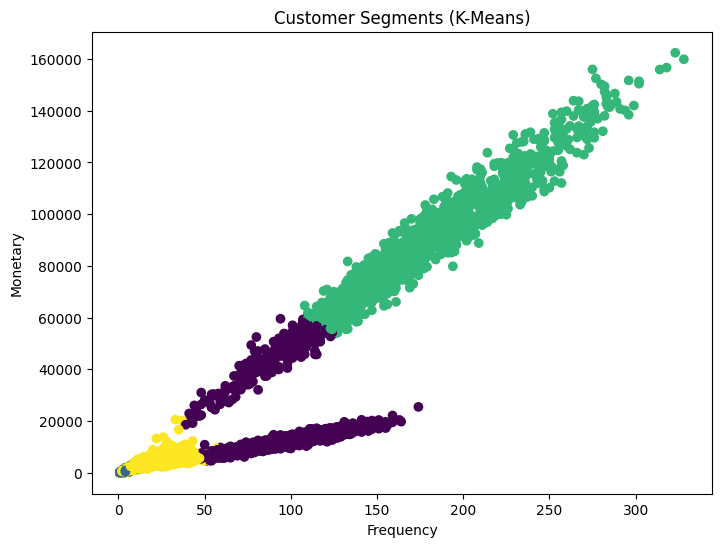

In [1]:
# =========================================
# 🧩 Customer Segmentation for Fashion App
# Jun 2024 – Aug 2024
# =========================================

# STEP 1️⃣ — Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import datetime as dt

# STEP 2️⃣ — Load dataset
# Upload your CSV (use left sidebar in Colab → Files → Upload)


# Replace the file name with your uploaded one
df = pd.read_csv("fashion_customer_transactions.csv")

# STEP 3️⃣ — Explore data
print("Dataset shape:", df.shape)
print(df.head())

# STEP 4️⃣ — Feature Engineering (RFM)
# Recency, Frequency, Monetary
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
snapshot_date = df["InvoiceDate"].max() + dt.timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,  # Recency
    "InvoiceNo": "count",                                     # Frequency
    "TotalAmount": "sum"                                      # Monetary
}).rename(columns={
    "InvoiceDate": "Recency",
    "InvoiceNo": "Frequency",
    "TotalAmount": "Monetary"
}).reset_index()

print("\nRFM Table:")
print(rfm.head())

# STEP 5️⃣ — Scale the data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

# STEP 6️⃣ — Elbow Method to find optimal k
inertia = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, "bo-")
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()

# STEP 7️⃣ — Apply K-Means with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

# STEP 8️⃣ — Cluster Summary
cluster_summary = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "CustomerID": "count"
}).rename(columns={"CustomerID": "NumCustomers"}).reset_index()

print("\nCluster Summary:")
print(cluster_summary)

# STEP 9️⃣ — Interpret clusters manually (you can label as below)
rfm["Segment"] = rfm["Cluster"].map({
    0: "High-Value Loyalists",
    1: "Bargain Seekers",
    2: "One-time Buyers",
    3: "Churn Risks"
})

print("\nSegmented Data (Sample):")
print(rfm.head())

# STEP 🔟 — Visualize segments
plt.figure(figsize=(8, 6))
plt.scatter(rfm["Frequency"], rfm["Monetary"], c=rfm["Cluster"], cmap="viridis")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Segments (K-Means)")
plt.show()
